In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from urllib.parse import urlparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import (
    roc_curve, auc as auc_fn, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

plt.rcParams["axes.unicode_minus"] = False

The Number of samples is : 61065
The Number of Features is : 17
________________________________
Distribution of Classes : classification
0    36000
1    25065
Name: count, dtype: int64
Numer of null samples :  0


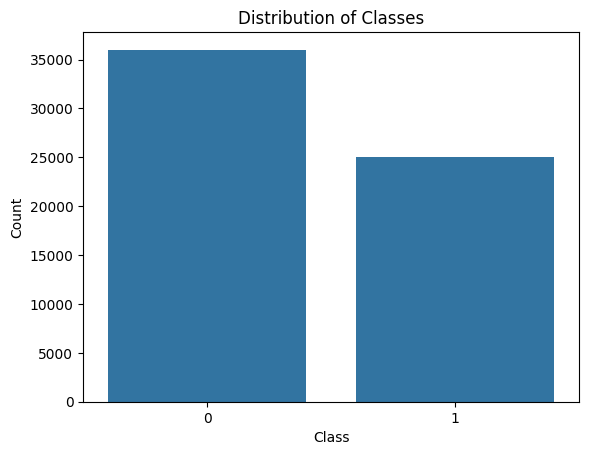

In [ ]:
df = pd.read_csv('/content/csic_database.csv')
N_samples= df.shape[0]
N_feature= df.shape[1]
print('The Number of samples is :',N_samples)
print('The Number of Features is :',N_feature)
print('________________________________',end='\n')

print('Distribution of Classes :',df["classification"].value_counts())
print('Numer of null samples : ',df["classification"].isnull().sum())

sns.countplot(data=df, x="classification")

plt.title("Distribution of Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [ ]:
print(df.head())

  Unnamed: 0 Method                                         User-Agent  \
0     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
1     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
2     Normal   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
3     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
4     Normal   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   

     Pragma Cache-Control                                             Accept  \
0  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
1  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
2  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
3  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
4  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   

                    Accept-encoding               Accept-charset language 

In [ ]:
print(df.tail())

     Unnamed: 0 Method                                         User-Agent  \
6898     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
6899     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
6900     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
6901     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
6902     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   

        Pragma Cache-Control  \
6898  no-cache      no-cache   
6899  no-cache      no-cache   
6900  no-cache      no-cache   
6901  no-cache      no-cache   
6902  no-cache      no-cache   

                                                 Accept  \
6898  text/xml,application/xml,application/xhtml+xml...   
6899  text/xml,application/xml,application/xhtml+xml...   
6900  text/xml,application/xml,application/xhtml+xml...   
6901  text/xml,application/xml,application/xhtml+xml...   
6902  text/xml,application/xml,application/xhtml+

In [ ]:
print('عدد القيم الفارغة بكل عمود')
print((df.isnull().sum()) )

عدد القيم الفارغة بكل عمود
Unnamed: 0            0
Method                0
User-Agent            0
Pragma                0
Cache-Control         0
Accept                0
Accept-encoding       0
Accept-charset        0
language              0
host                  0
cookie                0
content-type       5368
connection            0
lenght             5368
content            5368
classification        0
URL                   0
dtype: int64


In [ ]:
print(df.nunique())

Unnamed: 0            1
Method                2
User-Agent            1
Pragma                1
Cache-Control         1
Accept                1
Accept-encoding       1
Accept-charset        1
language              1
host                  1
cookie             6903
content-type          1
connection            2
lenght               97
content             961
classification        1
URL                 990
dtype: int64


In [ ]:
print(df.duplicated(subset=['URL']).sum())

5913


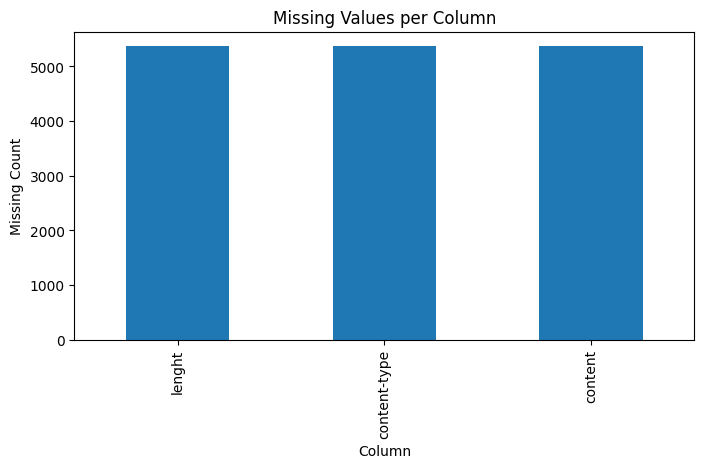

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.show()

# Feature Selected

In [ ]:

df = df.rename(columns={"lenght": "content_length_header"})

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

cols_to_drop = [
    "User-Agent",
    "Pragma",           # 1 unique  → لا معلومة
    "Cache-Control",    # 1 unique  → لا معلومة
    "Accept",           # 1 unique  → لا معلومة
    "Accept-encoding",  # 1 unique  → لا معلومة
    "Accept-charset",   # 1 unique  → لا معلومة
    "language",         # 1 unique  → لا معلومة
    "host",             # 2 unique  → localhost فقط
    "cookie",           # 61065 unique → session IDs = noise خطير
    "content-type",     # 1 unique  → لا معلومة
    "connection",       # 2 unique  → لا معلومة
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print('The rest Column :')
print(df.columns.tolist())

The rest Column :
['Method', 'content_length_header', 'content', 'classification', 'URL']


# Target

In [ ]:
target_col = "classification"
y = df[target_col]

if y.dtype == "object":
    y = y.astype("category").cat.codes

X = df.drop(columns=[target_col])

print("\nTarget distribution:")
print(pd.Series(y).value_counts())


Target distribution:
classification
0    36000
1    25065
Name: count, dtype: int64


# Features Extraction

In [ ]:
import numpy as np
import pandas as pd
import re
from urllib.parse import urlparse


def safe_str(value):
    if pd.isna(value):
        return ""
    return str(value)

def count_dot(text):
    return safe_str(text).count(".")

def count_dir(text):
    return urlparse(safe_str(text)).path.count("/")

def count_embed(text):
    return urlparse(safe_str(text)).path.count("//")

def count_http(text):
    return safe_str(text).lower().count("http")

def count_percent(text):
    return safe_str(text).count("%")

def count_question(text):
    return safe_str(text).count("?")

def count_hyphen(text):
    return safe_str(text).count("-")

def count_equal(text):
    return safe_str(text).count("=")

def text_length(text):
    return len(safe_str(text))

def hostname_length(text):
    return len(urlparse(safe_str(text)).netloc)

def digit_count(text):
    return sum(ch.isdigit() for ch in safe_str(text))

def letter_count(text):
    return sum(ch.isalpha() for ch in safe_str(text))

def special_char_count(text):
    text = safe_str(text)
    return len(re.sub(r"[a-zA-Z0-9\s]", "", text))

def number_of_parameters(text):
    query = urlparse(safe_str(text)).query
    if query == "":
        return 0
    return len(query.split("&"))

def is_encoded(text):
    return int("%" in safe_str(text))

def unusual_character_ratio(text):
    text = safe_str(text)
    if len(text) == 0:
        return 0
    unusual = re.sub(r"[a-zA-Z0-9\s\-._]", "", text)
    return len(unusual) / len(text)

def shortening_service(text):
    text = safe_str(text).lower()
    shorteners = [
        "bit.ly", "goo.gl", "tinyurl", "t.co", "ow.ly", "is.gd",
        "buff.ly", "adf.ly", "bit.do", "cutt.us", "rebrand.ly",
        "tiny.cc", "shorturl.at", "lnkd.in"
    ]
    return int(any(service in text for service in shorteners))

from urllib.parse import urlparse, unquote

def parse_url_parts(url):
    url = safe_str(url)
    url = unquote(url)  # يفك الترميز مرة واحدة
    parsed = urlparse(url)

    path = parsed.path
    query = parsed.query

    return path, query



from collections import Counter
import math

def shannon_entropy(text):
    text = safe_str(text)
    if not text:
        return 0

    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]

    return -sum(p * math.log2(p) for p in probs)

# =========================
# 5. Feature Extraction — بدون TF-IDF
# يعتمد على السلوك فقط لا على القيم الحرفية
# =========================
def get_url_text(data):
    data = pd.DataFrame(data)
    return data["URL"].fillna("").astype(str)


def get_content_text(data):
    data = pd.DataFrame(data)
    return data["content"].fillna("").astype(str)

def extract_manual_features(data):
    data = pd.DataFrame(data).copy()
    features = pd.DataFrame(index=data.index)

    # --- URL Features ---
    if "URL" in data.columns:
        url_col = data["URL"].apply(safe_str)
    else:
        url_col = pd.Series([""] * len(data), index=data.index)

    # الـ features الأصلية
    # features["url_entropy"] = url_col.apply(shannon_entropy)
    # features["content_entropy"] = content_col.apply(shannon_entropy)

    features["url_length"]          = url_col.apply(text_length)
    features["url_count_dot"]       = url_col.apply(count_dot)
    features["url_count_dir"]       = url_col.apply(count_dir)
    features["url_count_embed"]     = url_col.apply(count_embed)
    features["url_count_http"]      = url_col.apply(count_http)
    features["url_count_percent"]   = url_col.apply(count_percent)
    features["url_count_question"]  = url_col.apply(count_question)
    features["url_count_hyphen"]    = url_col.apply(count_hyphen)
    features["url_count_equal"]     = url_col.apply(count_equal)
    features["url_digit_count"]     = url_col.apply(digit_count)
    features["url_letter_count"]    = url_col.apply(letter_count)
    features["url_special_count"]   = url_col.apply(special_char_count)
    features["url_is_encoded"]      = url_col.apply(is_encoded)
    features["url_unusual_ratio"]   = url_col.apply(unusual_character_ratio)
    # features["url_suspicious_score"]= url_col.apply(suspicious_score)
    features["url_hostname_length"] = url_col.apply(hostname_length)
    features["url_num_parameters"]  = url_col.apply(number_of_parameters)
    features["url_shortener"]       = url_col.apply(shortening_service)

    # الـ features الجديدة
    features["url_path_depth"]   = url_col.apply(
        lambda x: urlparse(safe_str(x)).path.count("/")
    )
    features["url_path_length"]  = url_col.apply(
        lambda x: len(urlparse(safe_str(x)).path)
    )
    features["url_query_length"] = url_col.apply(
        lambda x: len(urlparse(safe_str(x)).query)
    )
    features["url_has_extension"] = url_col.apply(
        lambda x: int("." in urlparse(safe_str(x)).path.split("/")[-1])
    )

    if "content" in data.columns:
        content_col = data["content"].apply(safe_str)
    else:
        content_col = pd.Series([""] * len(data), index=data.index)

    # الـ features الأصلية
    features["content_length"]          = content_col.apply(text_length)
    features["content_count_dot"]       = content_col.apply(count_dot)
    features["content_count_dir"]       = content_col.apply(count_dir)
    features["content_count_embed"]     = content_col.apply(count_embed)
    features["content_count_http"]      = content_col.apply(count_http)
    features["content_count_percent"]   = content_col.apply(count_percent)
    features["content_count_question"]  = content_col.apply(count_question)
    features["content_count_hyphen"]    = content_col.apply(count_hyphen)
    features["content_count_equal"]     = content_col.apply(count_equal)
    features["content_digit_count"]     = content_col.apply(digit_count)
    features["content_letter_count"]    = content_col.apply(letter_count)
    features["content_special_count"]   = content_col.apply(special_char_count)
    features["content_is_encoded"]      = content_col.apply(is_encoded)
    features["content_unusual_ratio"]   = content_col.apply(unusual_character_ratio)

    if "content_length_header" in data.columns:
        cl = data["content_length_header"].astype(str).str.extract(r"(\d+)")[0]
        features["content_length_header"] = pd.to_numeric(cl, errors="coerce").fillna(0)
    else:
        features["content_length_header"] = 0

    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    return features.astype(np.float64)

# Preprocessor

In [ ]:
categorical_cols = []

for col in ["Method", ]:
    if col in X.columns:
        categorical_cols.append(col)


# =========================
# 6. Preprocessor Pipeline
# =========================
categorical_cols = ["Method"] if "Method" in X.columns else []

preprocessor = ColumnTransformer(
    transformers=[
        (
            "manual_features",
            FunctionTransformer(extract_manual_features, validate=False),
            ["URL", "Method", "content"]
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            categorical_cols
        )
    ],
    remainder="drop"
)


# Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# Spliting Data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y,test_size=0.30,random_state=42,stratify=y)

print("\nTrain shape:", x_train.shape)
print("Test shape :", x_test.shape)


Train shape: (42745, 4)
Test shape : (18320, 4)


# Visual

In [ ]:
def plot_single_model(model_name, y_test, y_pred, y_score=None, is_proba=True):
    """
    y_score:
        - مصفوفة احتمالات (n_samples, n_classes) إن is_proba=True
        - أو decision_function scores إن is_proba=False
    """
    classes = np.unique(y_test)
    n_classes = len(classes)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Results: {model_name}", fontsize=15, fontweight="bold")

    # ---------- 1) Confusion Matrix ----------
    # نعرض الأرقام الخام (annot) فوق خلفية مُطبَّعة بالصفوف.
    # التطبيع بالصفوف: كل خلية = P(pred=j | true=i) → القطر = recall لكل صنف
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes, ax=axes[0],
        cbar_kws={"label": "Row-normalized rate"}, vmin=0, vmax=1
    )
    axes[0].set_title("Confusion Matrix\n(counts on row-normalized color)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # ---------- 2) ROC Curve ----------
    if y_score is not None:
        if n_classes == 2:
            # في الثنائي: نحتاج scores للصنف الموجب فقط
            if is_proba:
                pos_scores = y_score[:, 1]
            else:
                pos_scores = y_score  # decision_function 1D
            fpr, tpr, _ = roc_curve(y_test, pos_scores)
            axes[1].plot(fpr, tpr, lw=2,
                         label=f"AUC = {auc_fn(fpr, tpr):.3f}")
        else:
            # متعدد الأصناف: One-vs-Rest
            y_bin = label_binarize(y_test, classes=classes)
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
                axes[1].plot(fpr, tpr, lw=1.5,
                             label=f"{classes[i]}: AUC={auc_fn(fpr, tpr):.3f}")
        axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.5)")
        axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
        axes[1].set_title("ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc="lower right", fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "No scores available", ha="center", va="center")
        axes[1].set_title("ROC Curve (N/A)")

    # ---------- 3) Per-class Precision / Recall / F1 ----------
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=classes, zero_division=0
    )
    x = np.arange(n_classes)
    w = 0.25
    axes[2].bar(x - w, p, w, label="Precision")
    axes[2].bar(x,     r, w, label="Recall")
    axes[2].bar(x + w, f, w, label="F1")
    axes[2].set_xticks(x); axes[2].set_xticklabels(classes)
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title("Per-class Metrics")
    axes[2].set_ylabel("Score")
    axes[2].legend(fontsize=9)
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"plot_{model_name.replace(' ', '_')}.png", dpi=120, bbox_inches="tight")
    plt.show()



Training: Logistic Regression
CV Train Accuracy : 0.7813
CV Test  Accuracy : 0.7804 ± 0.0043
CV Test  F1       : 0.7807 ± 0.0039
✅ لا overfitting: gap = 0.0009

Train Accuracy : 0.7698
Test  Accuracy : 0.7700
Precision      : 0.7707
Recall         : 0.7700
F1             : 0.7703
ROC AUC        : 0.8544

Confusion Matrix:
[[8621 2179]
 [2035 5485]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80     10800
           1       0.72      0.73      0.72      7520

    accuracy                           0.77     18320
   macro avg       0.76      0.76      0.76     18320
weighted avg       0.77      0.77      0.77     18320



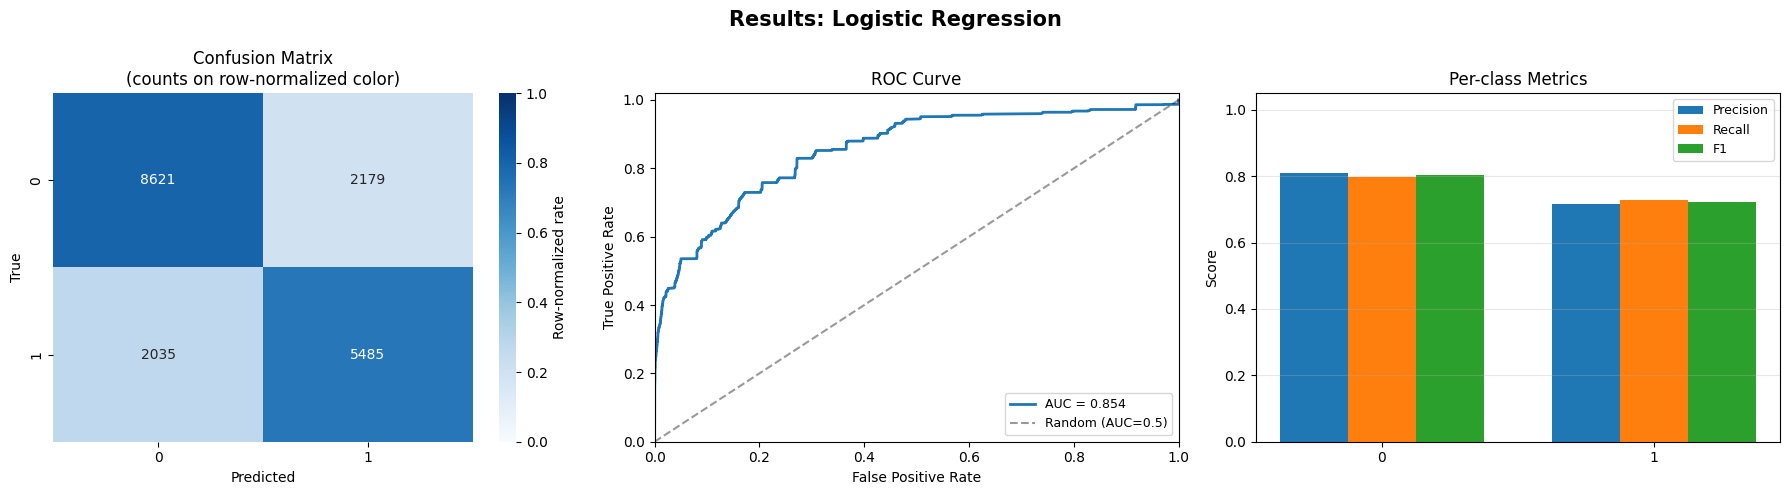


Training: Linear SVM
CV Train Accuracy : 0.7776
CV Test  Accuracy : 0.7766 ± 0.0039
CV Test  F1       : 0.7764 ± 0.0039
✅ لا overfitting: gap = 0.0010

Train Accuracy : 0.7776
Test  Accuracy : 0.7786
Precision      : 0.7777
Recall         : 0.7786
F1             : 0.7780
ROC AUC        : 0.8554

Confusion Matrix:
[[8887 1913]
 [2143 5377]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     10800
           1       0.74      0.72      0.73      7520

    accuracy                           0.78     18320
   macro avg       0.77      0.77      0.77     18320
weighted avg       0.78      0.78      0.78     18320



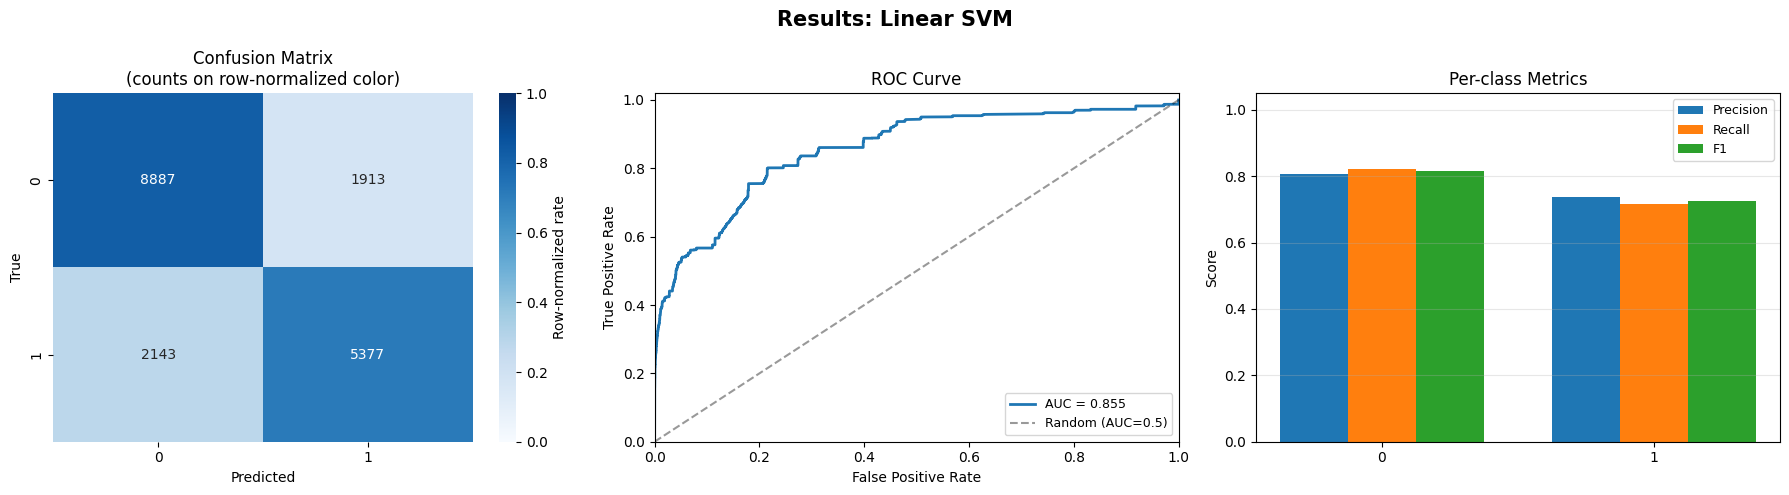


Training: Random Forest
CV Train Accuracy : 0.9419
CV Test  Accuracy : 0.9197 ± 0.0009
CV Test  F1       : 0.9201 ± 0.0009
✅ لا overfitting: gap = 0.0223

Train Accuracy : 0.9423
Test  Accuracy : 0.9222
Precision      : 0.9252
Recall         : 0.9222
F1             : 0.9226
ROC AUC        : 0.9852

Confusion Matrix:
[[9769 1031]
 [ 395 7125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     10800
           1       0.87      0.95      0.91      7520

    accuracy                           0.92     18320
   macro avg       0.92      0.93      0.92     18320
weighted avg       0.93      0.92      0.92     18320



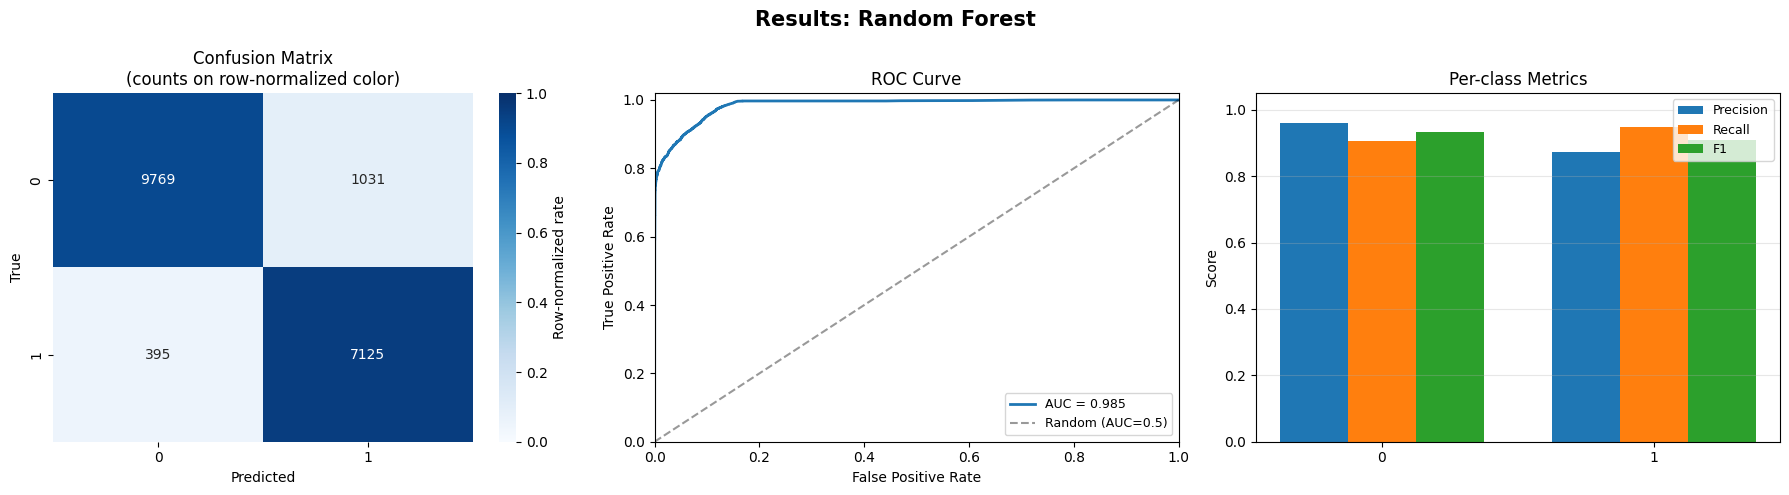

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for model_name, classifier in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print("="*60)

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring=["f1_weighted", "accuracy"],
        return_train_score=True,
        n_jobs=-1
    )

    print(f"CV Train Accuracy : {cv_results['train_accuracy'].mean():.4f}")
    print(f"CV Test  Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"CV Test  F1       : {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

    overfitting_gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
    if overfitting_gap > 0.05:
        print(f"⚠️  Overfitting مشتبه: gap = {overfitting_gap:.4f}")
    else:
        print(f"✅ لا overfitting: gap = {overfitting_gap:.4f}")

    # التدريب النهائي
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    train_acc = model.score(x_train, y_train)
    test_acc  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # ----- حساب الـ scores مرة واحدة للـ AUC وللرسم -----
    clf = model.named_steps["classifier"]
    auc = None
    y_score_for_plot = None
    is_proba = True

    if hasattr(clf, "predict_proba"):
        y_prob = model.predict_proba(x_test)
        y_score_for_plot = y_prob
        is_proba = True
        if y_prob.shape[1] == 2:
            auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    elif hasattr(clf, "decision_function"):
        y_dec = model.decision_function(x_test)
        y_score_for_plot = y_dec
        is_proba = False
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_dec)
        else:
            auc = roc_auc_score(y_test, y_dec, multi_class="ovr")

    results.append({
        "Model": model_name,
        "CV Accuracy": round(cv_results['test_accuracy'].mean(), 4),
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC AUC": round(auc, 4) if auc else None,
        "Overfitting Gap": round(overfitting_gap, 4)
    })

    print(f"\nTrain Accuracy : {train_acc:.4f}")
    print(f"Test  Accuracy : {test_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1             : {f1:.4f}")
    if auc:
        print(f"ROC AUC        : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # ----- العرض البصري لهذا النموذج -----
    plot_single_model(model_name, y_test, y_pred, y_score_for_plot, is_proba)


Final Model Comparison
              Model  CV Accuracy  Train Accuracy  Test Accuracy  Precision  Recall     F1  ROC AUC  Overfitting Gap
      Random Forest       0.9197          0.9423         0.9222     0.9252  0.9222 0.9226   0.9852           0.0223
         Linear SVM       0.7766          0.7776         0.7786     0.7777  0.7786 0.7780   0.8554           0.0010
Logistic Regression       0.7804          0.7698         0.7700     0.7707  0.7700 0.7703   0.8544           0.0009


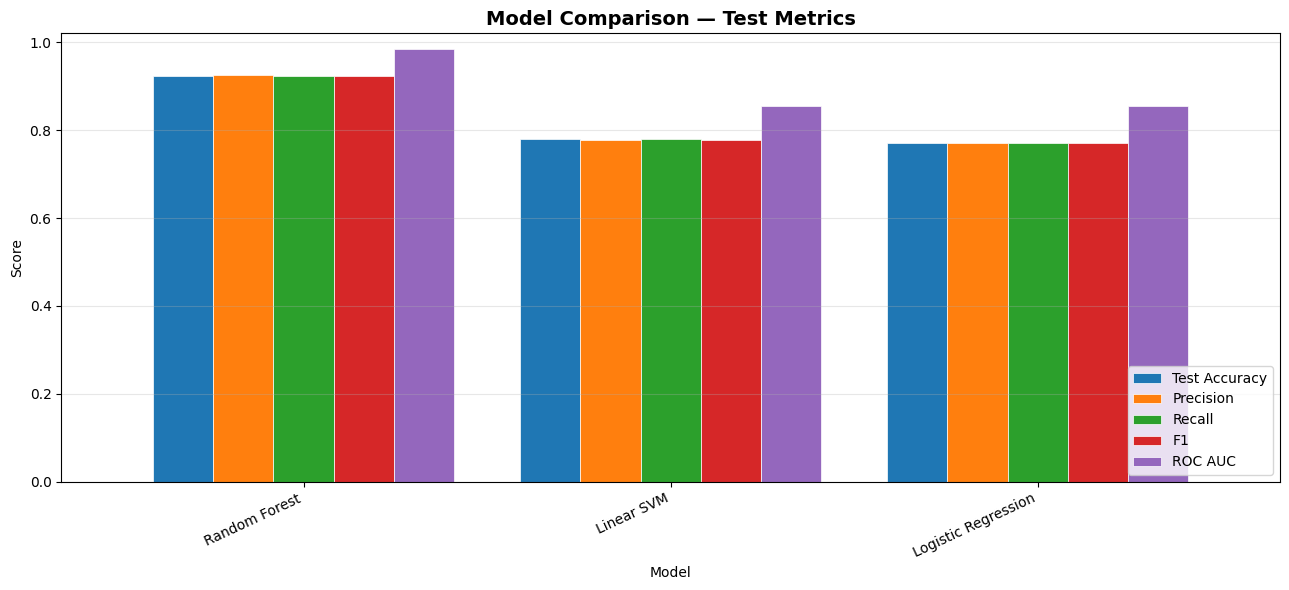

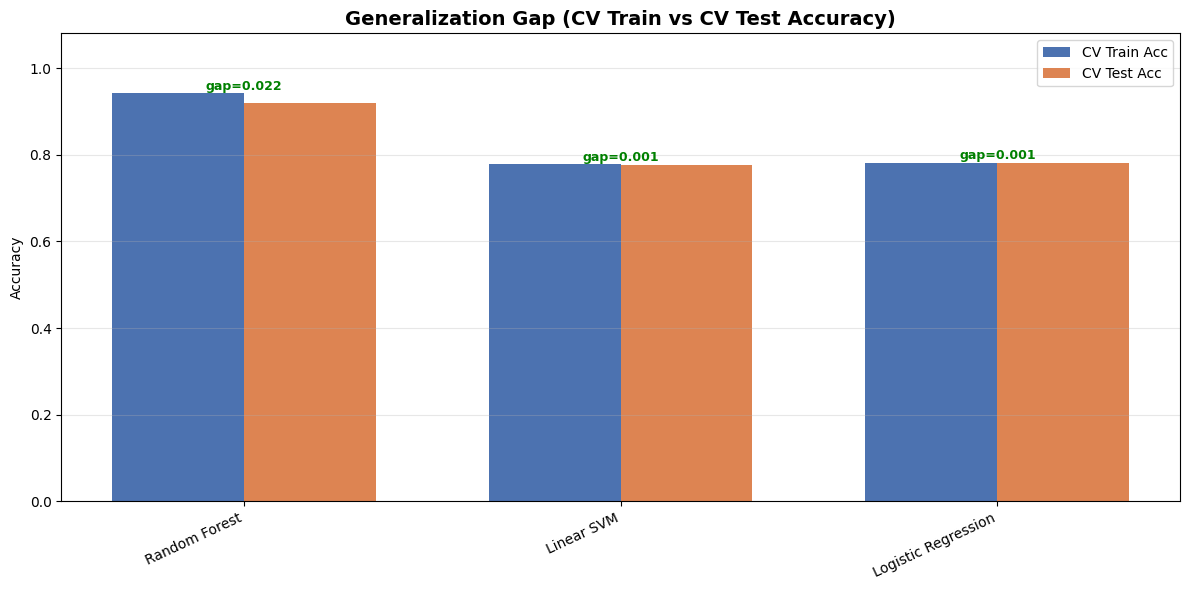

In [ ]:
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Final Model Comparison")
print("="*60)
print(results_df.sort_values(by="F1", ascending=False).to_string(index=False))

# نُعيد ترتيب الـ DataFrame حسب F1 للعرض المنطقي
df_plot = results_df.set_index("Model").sort_values("F1", ascending=False)

# ---------- A) مقارنة المقاييس الأساسية ----------
metrics = ["Test Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
metrics = [m for m in metrics if df_plot[m].notna().any()]
ax = df_plot[metrics].plot(kind="bar", figsize=(13, 6), width=0.82,
                           edgecolor="white", linewidth=0.5)
ax.set_title("Model Comparison — Test Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.02)
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

# ---------- B) Overfitting: CV Train vs CV Test ----------
# ملاحظة: الـ gap محسوب من CV، لذا نقارن CV Train ضد CV Test (Accuracy)
# نحتاج CV Train — لم نخزّنه، فنستنتجه: CV_Train = CV_Test + gap
fig, ax = plt.subplots(figsize=(12, 6))
cv_test = df_plot["CV Accuracy"].values
gaps    = df_plot["Overfitting Gap"].values
cv_train = cv_test + gaps  # لأن gap = train - test
xpos = np.arange(len(df_plot)); w = 0.35
ax.bar(xpos - w/2, cv_train, w, label="CV Train Acc", color="#4C72B0")
ax.bar(xpos + w/2, cv_test,  w, label="CV Test Acc",  color="#DD8452")
for i, g in enumerate(gaps):
    ymax = max(cv_train[i], cv_test[i])
    ax.text(i, ymax + 0.008, f"gap={g:.3f}", ha="center", fontsize=9,
            color="red" if g > 0.05 else "green", fontweight="bold")
ax.set_xticks(xpos); ax.set_xticklabels(df_plot.index, rotation=25, ha="right")
ax.set_ylim(0, 1.08)
ax.set_title("Generalization Gap (CV Train vs CV Test Accuracy)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_overfitting.png", dpi=120, bbox_inches="tight")
plt.show()